c:\Users\Admin\Desktop\PracaMGR\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu
Przygotowywanie segmentów AST...
Plik 214/214
✅ Liczba cykli: 1703
✅ Najlepszy model AST załadowany.
ICBHI zapisany w checkpointcie: 60.45%

EWALUACJA KLASYFIKACJI AST
AST: batch 107/107

WYNIKI AST
SEN: 49.28%
SPE: 71.62%
ICBHI SCORE: 60.45%

Czułość dla klas:
    Normal: 71.6% (573/800)
  Crackles: 54.5% (282/517)
   Wheezes: 45.5% (102/224)
      Both: 37.7% (61/162)


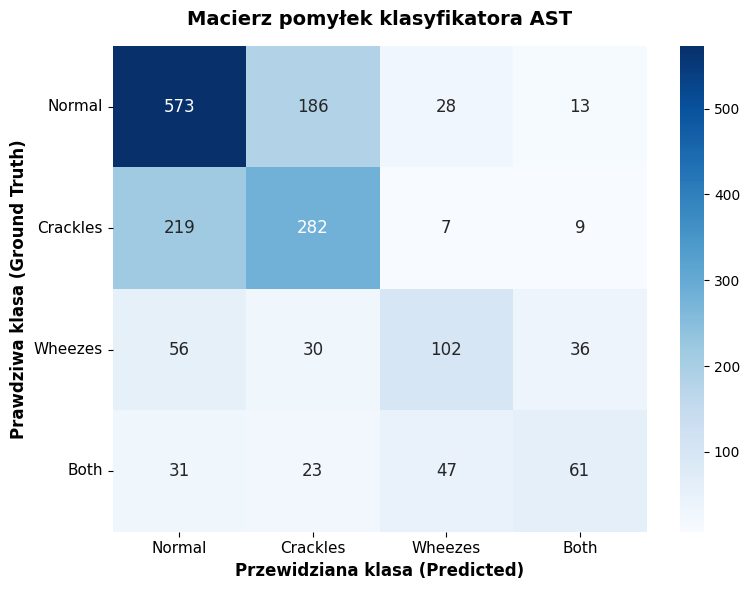

In [1]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
import librosa
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import signal
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from torch.utils.data import Dataset, DataLoader
from transformers import ASTFeatureExtractor, ASTModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dataset_dir = "data/audio_and_txt_files/"
save_ast_path = "models/best_ast_model.pth"

CLF_SR = 16000
CLF_SEG_LEN_SEC = 5
CLF_SEG_TARGET_LEN = CLF_SR * CLF_SEG_LEN_SEC
BATCH_SIZE_CLF = 16

CLASS_NAMES = ["Normal", "Crackles", "Wheezes", "Both"]

print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

ast_extractor = ASTFeatureExtractor.from_pretrained(
    "MIT/ast-finetuned-audioset-10-10-0.4593"
)


def butter_highpass_filter(data, cutoff=50.0, fs=4000, order=4):
    nyq = 0.5 * fs
    b, a = signal.butter(order, cutoff / nyq, btype="high", analog=False)
    return signal.filtfilt(b, a, data)


def encode_label(c, w):
    return int(c) * 1 + int(w) * 2


txt_files = glob.glob(os.path.join(dataset_dir, "*.txt"))

patient_ids = sorted(
    list(set(os.path.basename(f).split("_")[0] for f in txt_files))
)

_, test_patients = train_test_split(
    patient_ids,
    test_size=0.2,
    random_state=42
)

test_audio_files = [
    f for f in glob.glob(os.path.join(dataset_dir, "*.wav"))
    if os.path.basename(f).split("_")[0] in test_patients
]


class ICBHIASTDataset(Dataset):
    def __init__(self, audio_files):
        self.segments = []

        print("Przygotowywanie segmentów AST...")

        for i, wav_path in enumerate(audio_files, 1):

            print(
                f"\rPlik {i}/{len(audio_files)}",
                end="",
                flush=True
            )

            txt_path = wav_path.replace(".wav", ".txt")

            if not os.path.exists(txt_path):
                continue

            try:
                audio, _ = librosa.load(wav_path, sr=CLF_SR)
            except:
                continue

            audio = butter_highpass_filter(audio, fs=CLF_SR)

            with open(txt_path, "r") as f:
                for line in f:

                    parts = line.strip().split("\t")

                    if len(parts) < 4:
                        continue

                    s = int(float(parts[0]) * CLF_SR)
                    e = int(float(parts[1]) * CLF_SR)

                    segment = audio[s:e]

                    if len(segment) < int(CLF_SR * 0.1):
                        continue

                    c = int(parts[2])
                    w = int(parts[3])

                    label = encode_label(c, w)

                    self.segments.append((segment, label))

        print()
        print(f"✅ Liczba cykli: {len(self.segments)}")

    def __len__(self):
        return len(self.segments)

    def __getitem__(self, idx):

        segment, label = self.segments[idx]

        segment = segment.copy().astype(np.float32)

        if len(segment) > CLF_SEG_TARGET_LEN:
            segment = segment[:CLF_SEG_TARGET_LEN]

        elif len(segment) < CLF_SEG_TARGET_LEN:
            segment = np.pad(
                segment,
                (0, CLF_SEG_TARGET_LEN - len(segment))
            )

        inputs = ast_extractor(
            segment,
            sampling_rate=CLF_SR,
            padding="max_length",
            return_tensors="pt"
        )

        return (
            inputs.input_values.squeeze(0),
            torch.tensor(label, dtype=torch.long)
        )


test_dataset_clf = ICBHIASTDataset(test_audio_files)

test_loader_clf = DataLoader(
    test_dataset_clf,
    batch_size=BATCH_SIZE_CLF,
    shuffle=False,
    num_workers=0
)


class LungSoundAST(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()

        self.ast = ASTModel.from_pretrained(
            "MIT/ast-finetuned-audioset-10-10-0.4593"
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(768),
            nn.Dropout(0.3),
            nn.Linear(768, 512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, 128),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        out = self.ast(x)
        cls_tok = out.last_hidden_state[:, 0, :]
        return self.classifier(cls_tok)


ast_model = LungSoundAST(num_classes=4).to(device)

checkpoint = torch.load(
    save_ast_path,
    map_location=device,
    weights_only=False
)

ast_model.load_state_dict(checkpoint["model_state_dict"])
ast_model.eval()

print("✅ Najlepszy model AST załadowany.")

if "icbhi_score" in checkpoint:
    print(f"ICBHI zapisany w checkpointcie: {checkpoint['icbhi_score']:.2f}%")


print("\nEWALUACJA KLASYFIKACJI AST")

y_true = []
y_pred = []

with torch.no_grad():
    for i, (mels, labels) in enumerate(test_loader_clf, 1):

        print(
            f"\rAST: batch {i}/{len(test_loader_clf)}",
            end="",
            flush=True
        )

        logits = ast_model(mels.to(device))

        preds = torch.argmax(logits, dim=1)

        y_pred.extend(preds.cpu().numpy())
        y_true.extend(labels.numpy())

print()

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1, 2, 3]
)

total_correct_path = cm[1, 1] + cm[2, 2] + cm[3, 3]

total_path = (
    np.sum(cm[1, :])
    + np.sum(cm[2, :])
    + np.sum(cm[3, :])
)

SEN = total_correct_path / total_path if total_path > 0 else 0

normal_total = np.sum(cm[0, :])
SPE = cm[0, 0] / normal_total if normal_total > 0 else 0

ICBHI_SCORE = 0.5 * (SEN + SPE)

print("\nWYNIKI AST")
print(f"SEN: {SEN * 100:.2f}%")
print(f"SPE: {SPE * 100:.2f}%")
print(f"ICBHI SCORE: {ICBHI_SCORE * 100:.2f}%")

print("\nCzułość dla klas:")

for i, name in enumerate(CLASS_NAMES):

    total_class = np.sum(cm[i, :])

    if total_class > 0:
        class_recall = cm[i, i] / total_class

        print(
            f"{name:>10}: "
            f"{class_recall * 100:.1f}% "
            f"({cm[i, i]}/{total_class})"
        )


fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    annot_kws={"size": 12},
    ax=ax
)

ax.set_title(
    "Macierz pomyłek klasyfikatora AST",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_ylabel(
    "Prawdziwa klasa (Ground Truth)",
    fontsize=12,
    fontweight="bold"
)

ax.set_xlabel(
    "Przewidziana klasa (Predicted)",
    fontsize=12,
    fontweight="bold"
)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11, rotation=0)
plt.tight_layout()
plt.show()